# **Data merge and cleaning - ACUS Zamora Chinchipe**

Author: Daning Montaño - Ocampo

Kernel: R

Se fusiona la base de datos de BNDB y GBIF para su posterior limpieza de datos basado en filtros aplicados a metadatos, nivel taxonómico y validación del nombre científico basado en GBIF.

# **1. Packages and libraries**

In [1]:
suppressMessages({
library(dplyr)
library(readr)
library(bdc) ## data cleaning
library(lubridate)
library(stringr)
library(doParallel)
library(CoordinateCleaner)
library(sf)
library(purrr)
library(tibble)
library(rgbif)})

Warning messages:
1: package ‘dplyr’ was built under R version 4.3.3 
2: package ‘readr’ was built under R version 4.3.3 
3: package ‘lubridate’ was built under R version 4.3.3 
4: package ‘doParallel’ was built under R version 4.3.3 


# **2. Cut data based on ACUS**

## 2.1 Load raw data

In [2]:
gbfi = read_delim("../../../DATOS/Datasets/Biodiversidad/occurrence_gbif.txt",delim = "\t")

Rows: 706176 Columns: 230
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (127): accessRights, bibliographicCitation, language, license, publishe...
dbl   (26): gbifID, individualCount, organismQuantity, startDayOfYear, endDa...
lgl   (71): dataGeneralizations, caste, pathway, associatedOccurrences, asso...
dttm   (5): modified, dateIdentified, lastInterpreted, lastParsed, lastCrawled
date   (1): georeferencedDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 


In [3]:
bndb = read_csv("../../../DATOS/Datasets/Biodiversidad/occurrences_bndb.csv")

Rows: 60853 Columns: 92
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (63): institutionCode, collectionCode, ownerInstitutionCode, collection...
dbl  (14): id, taxonID, year, month, day, startDayOfYear, endDayOfYear, indi...
lgl  (14): subgenus, eventID, informationWithheld, dataGeneralizations, asso...
dttm  (1): modified

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 


In [4]:
bioweb = read_csv("../../../DATOS/Datasets/Biodiversidad/Bioweb/bioweb_unido_total.csv") %>%
  filter(especie != "Indeterminado") %>%
  mutate(scientificName = paste(genero, especie, sep = " "))%>%
  mutate(id = paste(numeroMuseo, numeroCampo, sep = "_"))


Rows: 10390 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (23): numeroMuseo, numeroCampo, reino, filum, clase, orden, familia, ge...
dbl   (3): altitudMax, altitudMin, tejidos
lgl   (6): continente, fechaVerbatim, subespecie, forma, tipo, cita
dttm  (3): fechaInicioColeccion, fechaFinColeccion, fechaIdentificacion

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Warning message:
One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 


## 2.2. Load Grids - ACUS

In [5]:
grids_1km = st_read("../../../DATOS/SHP/Grids/grid_zamora_ch_buffer_1km.shp") |> 
  st_transform(4326) ## transform coordinates

Reading layer `grid_zamora_ch_buffer_1km' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Grids\grid_zamora_ch_buffer_1km.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 15779 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 794083.7 ymax: 9631351
Projected CRS: WGS 84 / UTM zone 17S


## 2.3. Extract only ID per dataset and Coordinates

In [6]:
gbfi_coordinates = gbfi|> select(gbifID, decimalLatitude, decimalLongitude)|> ## select only ids and coordinates
  filter(!is.na(decimalLatitude))|> # filter NA coordinates
  filter(!is.na(decimalLongitude))|># filter NA coordinates
  st_as_sf(coords = c("decimalLongitude", "decimalLatitude"), crs = 4326) |> # create sf object
  st_transform(4326)|>  # transform to 4326 system
  st_filter(grids_1km, .predicate = st_within) # cut based on acus grids



bndb_coordinates = bndb|> select(id, decimalLatitude, decimalLongitude)|>
  filter(!is.na(decimalLatitude))|>
  filter(!is.na(decimalLongitude))|>
  st_as_sf(coords = c("decimalLongitude", "decimalLatitude"), crs = 4326) |>
  st_transform(4326)|>
  st_filter(grids_1km, .predicate = st_within)



bioweb_coordinates = bioweb|> select(id, latitude, longitude)|>
  mutate(latitude = as.numeric(latitude))|>
  mutate(longitude = as.numeric(longitude))|>
  filter(!is.na(latitude))|>
  filter(!is.na(longitude))|>
  st_as_sf(coords = c("longitude", "latitude"), crs = 4326) |>
  st_transform(4326)|>
  st_filter(grids_1km, .predicate = st_within)

Warning messages:
1: There was 1 warning in `mutate()`.
ℹ In argument: `latitude = as.numeric(latitude)`.
Caused by warning:
! NAs introduced by coercion 
2: There was 1 warning in `mutate()`.
ℹ In argument: `longitude = as.numeric(longitude)`.
Caused by warning:
! NAs introduced by coercion 


## 2.4. Select ocurrences based on id selected

In [7]:
gbfi_selected = gbfi %>%
  filter(gbifID %in% gbfi_coordinates$gbifID) ## select based on id

bndb_selected = bndb %>%
  filter(id %in% bndb_coordinates$id) ## select based on id

bioweb_selected = bioweb %>%
  filter(id %in% bioweb_coordinates$id) ## select based on id

## 2.5. Expor pre-processed data

In [8]:

clean_names <- function(df){
  names(df) <- names(df) |>
    str_trim() |>               # elimina espacios
    str_replace_all(" ", "") |> # elimina espacios internos
    str_replace_all("\\.", "")  # elimina puntos añadidos por R
  df
}

gbfi_selected  <- clean_names(gbfi_selected)
bndb_selected  <- clean_names(bndb_selected)
bioweb_selected <- clean_names(bioweb_selected)

write_csv(
  gbfi_selected,
  "../../../DATOS/Datasets/Biodiversidad/gbif_selected.csv",
  na = ""
)

write_csv(
  bndb_selected,
  "../../../DATOS/Datasets/Biodiversidad/bndb_selected.csv",
  na = ""
)

write_csv(
  bioweb_selected,
  "../../../DATOS/Datasets/Biodiversidad/bioweb_selected.csv",
  na = ""
)

## **2.6 Load and homogenize Data**

We used data from:
- Global Biodiversity Information Facility (GBIF)
- PUCE - museum
- Base nacional de datos de biodiversidad (BNDB)

To homogenize and clean the data from different databases we used "bdc" package. 

Metadata file contains the information of the different columns names of the databaases and assing a unique name in a single database.

In [9]:
metadata <- tibble::tibble(
  datasetName = c("GBIF", "BNDB","BIOWEB"),
  fileName = c(
    "../../../DATOS/Datasets/Biodiversidad/gbif_selected.csv",
    "../../../DATOS/Datasets/Biodiversidad/bndb_selected.csv",
    "../../../DATOS/Datasets/Biodiversidad/bioweb_selected.csv"
  ),
  scientificName = c("scientificName", "scientificName", "scientificName"),
  decimalLatitude = c("decimalLatitude", "decimalLatitude", "latitude"),
  decimalLongitude = c("decimalLongitude", "decimalLongitude", "longitude"),
  gbifID = c("gbifID", "id",  "id" ),
  occurrenceID = c("occurrenceID", "occurrenceID", "id"),
  collectionID = c("collectionID", "collectionID", NA),
  institutionCode = c("institutionCode", "institutionCode", NA),
  collectionCode = c("collectionCode", "collectionCode", NA),
  ownerInstitutionCode = c("ownerInstitutionCode", "ownerInstitutionCode", NA),
  basisOfRecord = c("basisOfRecord", "basisOfRecord", NA),
  individualCount = c("individualCount", "individualCount", NA),
  eventDate = c("eventDate", "eventDate","fechaInicioColeccion"),
  year = c("year", "year", NA),
  coordinateUncertaintyInMeters = c("coordinateUncertaintyInMeters", "coordinateUncertaintyInMeters", NA),
  higherClassification = c("higherClassification", "higherClassification", NA),
  kingdom = c("kingdom", "kingdom", "reino"),
  phylum = c("phylum", "phylum","filum"),
  class = c("class", "class", "clase"),
  order = c("order", "order", "orden"),
  genus = c("genus", "genus", "genero"),
  specificEpithet = c("specificEpithet", "specificEpithet", "especie"),
  taxonRank = c("taxonRank", "taxonRank", NA)
)

Load the data using metadata file parameters

In [10]:
database<-
  bdc_standardize_datasets(metadata = metadata,
                           format = "csv",
                           overwrite = T,
                           save_database = F)


print(head(database))

Standardizing GBIF file
Standardizing BNDB file
Standardizing BIOWEB file


Warning messages:
1: One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 
2: One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat) 


# A tibble: 6 × 23
  database_id scientificName         decimalLatitude   decimalLongitude gbifID  
  <chr>       <chr>                  <chr>             <chr>            <chr>   
1 BIOWEB_1    Weinmannia condorensis -4.6194445        -78.7830556      QCA_117…
2 BIOWEB_2    Trichomanes lucens     -4.6194445        -78.7830556      QCA_101…
3 BIOWEB_3    Aphelandra rosulata    -4.31666666666667 -78.65           QCA1268…
4 BIOWEB_4    Mayna odorata          -4.3175           -78.6858         QCA1843…
5 BIOWEB_5    Mayna odorata          -4.33333          -78.6524         QCA1846…
6 BIOWEB_6    Saurauia herthae       -4.33333          -78.66           QCA2275…
# ℹ 18 more variables: occurrenceID <chr>, eventDate <chr>, kingdom <chr>,
#   phylum <chr>, class <chr>, order <chr>, genus <chr>, specificEpithet <chr>,
#   collectionID <chr>, institutionCode <chr>, collectionCode <chr>,
#   ownerInstitutionCode <chr>, basisOfRecord <chr>, individualCount <chr>,
#   year <chr>, coordinateUncerta

Create a new column with the name of the data source

In [11]:

database$database_name =sub("_.*", "", database$database_id)
unique(database$database_name)

[1] "BIOWEB" "BNDB"   "GBIF"  

Inicial dimension of the dataset

In [12]:
dimension = database %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5532  0.774
2 BNDB           59617  8.34 
3 GBIF          649468 90.9  

In [13]:
len_0 = sum(dimension$n)
cat("Dataset size:", len_0)

Dataset size: 714617

# **3. Cleaning**

## 3.1. Clean repeated ocurrendIDs

In [14]:
database_1 = database %>%
  distinct(occurrenceID, .keep_all = TRUE)
dimension_1= database_1 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_1

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5532  0.818
2 BNDB           35903  5.31 
3 GBIF          634995 93.9  

In [15]:
len_1= sum(dimension_1$n)
cat("Dataset size:", len_1)

Dataset size: 676430

## 3.2. Select only species level data

We only keeped data from Species level. We filter using all the ways of species could be written.
NA values ara manteined despite the fact that they comes from BNDN data, wich does not have Taxon rank information, for this we delete using NA in taxon Name

In [16]:
unique(database_1$taxonRank)

 [1] NA           "Genus"      "Species"    "Family"     "Tribe"     
 [6] "Subspecies" "Morph"      "Phylum"     "Subgenus"   "GENUS"     
[11] "SPECIES"    "FAMILY"     "UNRANKED"   "SUBSPECIES" "CLASS"     
[16] "ORDER"      "VARIETY"    "KINGDOM"    "PHYLUM"     "FORM"      

In [17]:
database_2 = database_1 %>%
  filter(taxonRank %in% c( "Species","SPECIES","UNRANKED" ,"VARIETY",  "SUBSPECIES", "Subspecies", "species", "subspecies", "Species group", "Subspec", NA))  %>%
  filter(!is.na(scientificName ))
dimension_2 = database_2 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_2

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5532  0.915
2 BNDB           21611  3.57 
3 GBIF          577557 95.5  

In [18]:

len_2= sum(dimension_2$n)
cat("Dataset size:", len_2)

Dataset size: 604700

## 3.4 Filter date (1970 - 2024)

Exploration of year variable

In [19]:
database_2 <- database_2 |>
  mutate(
    eventDate = as.Date(substr(eventDate, 1, 10), format = "%Y-%m-%d"),
    year  = as.integer(format(eventDate, "%Y"))
  
  )

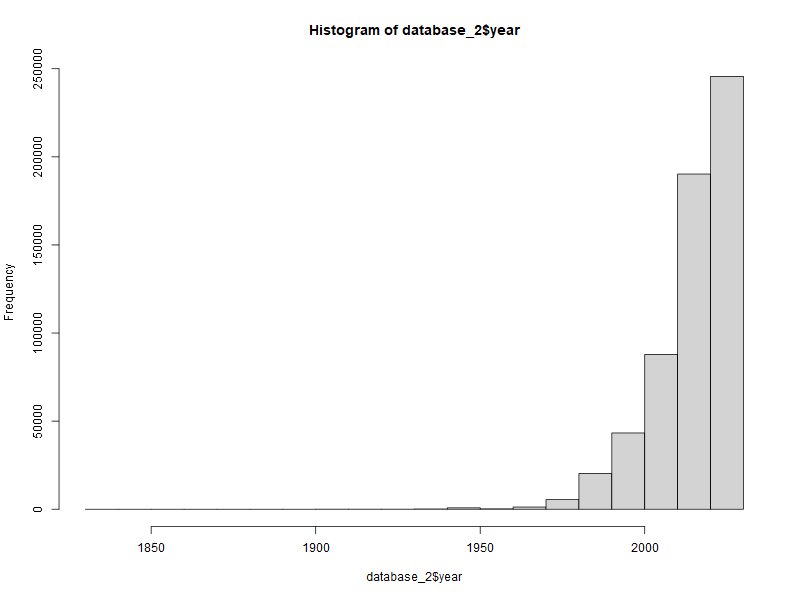

In [20]:
database_2$year = as.numeric(database_2$year)
hist(database_2$year)


Filtering 1970 - 2024

In [21]:
cat( "Min year", min(na.omit(database_2$year)))

Min year 1836

In [22]:
cat( "Max year", max(na.omit(database_2$year)))

Max year 2026

In [23]:
database_3 = database_2 %>%
  filter(!is.na(year)) %>%
  filter(year >= 1970) %>%
  filter(year <= 2025) 
dimension_3 = database_3 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_3

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5471  0.923
2 BNDB           19716  3.33 
3 GBIF          567532 95.8  

In [24]:

len_3= sum(dimension_3$n)
cat("Dataset size:", len_3)

Dataset size: 592719

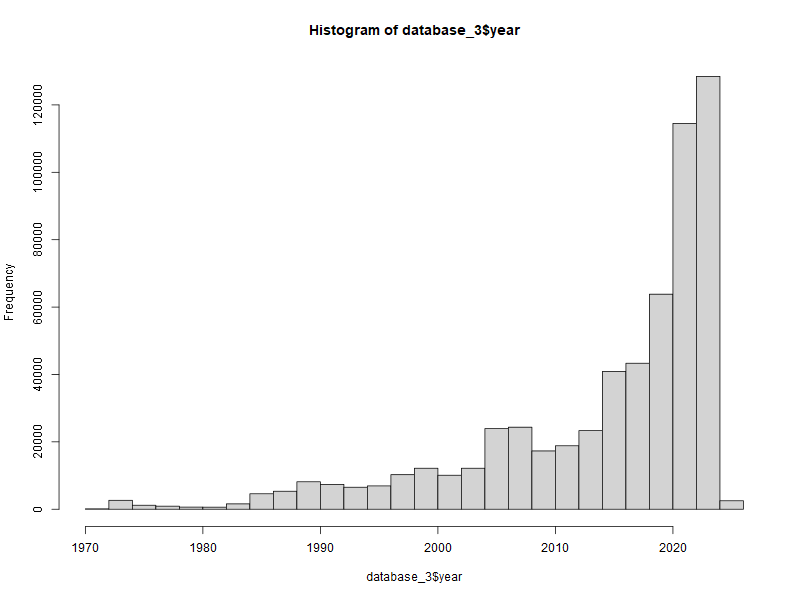

In [25]:
hist(database_3$year)

## 3.3. Delete Empy coordinates

In [26]:
database_4 = database_3 %>% 
  filter(!is.na(decimalLatitude)) %>% 
  filter(!is.na(decimalLongitude)) 
dimension_4 = database_4 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_4

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5471  0.923
2 BNDB           19716  3.33 
3 GBIF          567532 95.8  

In [27]:
len_4= sum(dimension_4$n)
cat("Dataset size:", len_4)

Dataset size: 592719

## 3.5. Filter coordinates out of range

The funtions from bdc packages add flags to the data frame to indicate if there is a problem with the data

In [28]:
database_5 = bdc_coordinates_outOfRange(data = database_4, 
lat = "decimalLatitude",
lon = "decimalLongitude") %>%
  filter(.coordinates_outOfRange == TRUE)

dimension_5 = database_5 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_5


bdc_coordinates_outOfRange:
Flagged 0 records.
One column was added to the database.



# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5471  0.923
2 BNDB           19716  3.33 
3 GBIF          567532 95.8  

In [29]:
len_5= sum(dimension_5$n)
cat("Dataset size:", len_5)

Dataset size: 592719

## 3.6. Filter coordinate Uncertainty

We only keep records with an accuracy of less than 10 km. If the value is NA, it is retained and other types of spatial filters are applied in the following steps.

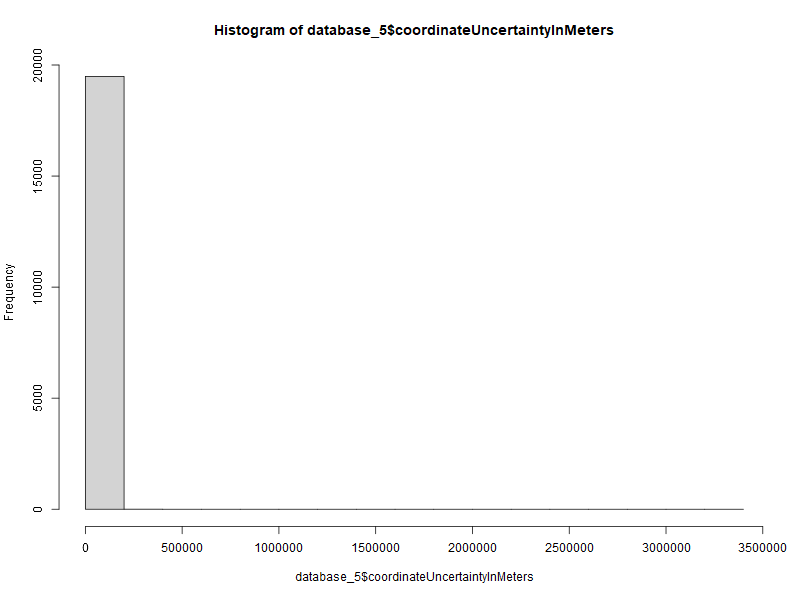

In [30]:
database_5$coordinateUncertaintyInMeters = as.numeric(database_5$coordinateUncertaintyInMeters)
hist(database_5$coordinateUncertaintyInMeters)

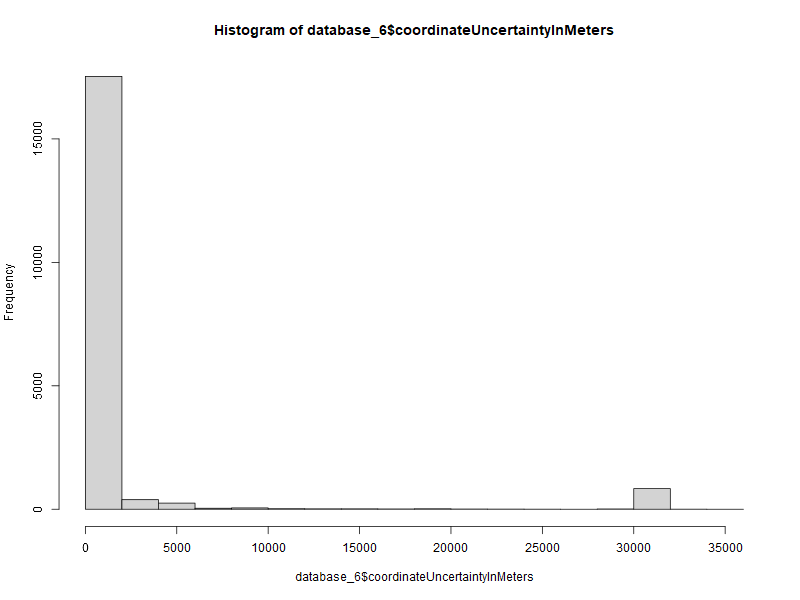

In [31]:
# Crear un nuevo dataframe filtrado a partir de database_5
database_6 <- database_5 |>
  
  # Filtrar registros según la incertidumbre de las coordenadas
  dplyr::filter(
    
    # Aplicar una condición diferente dependiendo de la fuente de datos
    dplyr::case_when(
      
      # Si el registro proviene de iNaturalist
      # se permiten valores de incertidumbre hasta 35 km
      institutionCode == "iNaturalist" ~ 
## en este caso inat cuando hay especies en peligro o bajo criterio de onservación obscure sus coordenadas (aprox 35 mil metros), 
## solo estas se mantienen porque tienen especies que pueden ser relevantes para el reporte, pero no el análisis
        coordinateUncertaintyInMeters <= 35000 | is.na(coordinateUncertaintyInMeters),
      
      # Para todos los demás repositorios
      # se usa un filtro de 5 km
      TRUE ~ 
        coordinateUncertaintyInMeters <= 5000 | is.na(coordinateUncertaintyInMeters)
    )
  )

# Visualizar la distribución de la incertidumbre espacial
# después del filtrado aplicado
hist(database_6$coordinateUncertaintyInMeters)


In [32]:
dimension_6 = database_6 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_6

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5471  0.923
2 BNDB           19680  3.32 
3 GBIF          567288 95.8  

In [33]:
len_6= sum(dimension_6$n)
cat("Dataset size:", len_6)

Dataset size: 592439

database_6

## 3.7. Classify only Species and uncertainties

In [34]:
identify_uncert <- function(name) {
  uncer_terms <- FALSE
  infraesp_names <- FALSE
  generic_only <- FALSE
  
  # Incertidumbre ("cf.", "aff.", "?", "nr.", "indet.", "undet")
  if (grepl("\\b(cf\\.?|aff\\.?|nr\\.?|indet\\.?|undet\\.?|\\?)\\b", name, ignore.case = TRUE)) {
    uncer_terms <- TRUE
  }
  

  
  # Género sin especie ("sp.", "spp.")
 # if (grepl("\\b(sp\\.|spp\\.)\\b", name, ignore.case = TRUE)) {
  #  generic_only <- TRUE
  #}
  
  return(list(
    name = name,
    uncer_terms = uncer_terms

    #generic_only = generic_only
  ))
}


In [35]:
sp_names = unique(database_6$scientificName)
uncertain_results <- map(sp_names , identify_uncert)
uncertain_results_df <- do.call(rbind, lapply(uncertain_results, as.data.frame))
uncertain_results_df

There were 40 warnings (use warnings() to see them)


                              name uncer_terms
1           Weinmannia condorensis       FALSE
2               Trichomanes lucens       FALSE
3              Aphelandra rosulata       FALSE
4                    Mayna odorata       FALSE
5                 Saurauia herthae       FALSE
6       Saurauia pseudostrigillosa       FALSE
7          Utricularia jamesoniana       FALSE
8             Trichomanes plumosum       FALSE
9                  Stelis gigantea       FALSE
10               Hortia brasiliana       FALSE
11            Enterosora parietina       FALSE
12             Digomphia densicoma       FALSE
13        Brachionidium condorense       FALSE
14            Isidrogalvia falcata       FALSE
15            Ceradenia kalbreyeri       FALSE
16               Gynoxys buxifolia       FALSE
17       Brachionidium dalstroemii       FALSE
18            Utricularia unifolia       FALSE
19           Podocarpus tepuiensis       FALSE
20              Gordonia fruticosa       FALSE
21         Gy

In [36]:
database_7 = database_6 %>%
  left_join(uncertain_results_df, by = c("scientificName" = "name"))%>%
  filter(uncer_terms == FALSE)# %>%
  #filter(generic_only == FALSE)
dimension_7 = database_7 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_7

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5471  0.923
2 BNDB           19680  3.32 
3 GBIF          567288 95.8  

In [37]:
len_7= sum(dimension_7$n)
cat("Dataset size:", len_7)

Dataset size: 592439

## 3.8. Cleaning names

In [38]:
database_7$ scientificName = paste(database_7$genus,database_7$specificEpithet, sep = " " )

sp_names = unique(database_7$scientificName)
sp_names_clean = bdc_clean_names(
  sp_names,
  save_outputs = FALSE
)


>> Family names prepended to scientific names were flagged and removed from 1 records.
>> Terms denoting taxonomic uncertainty were flagged and removed from 0 records.
>> Other issues, capitalizing the first letter of the generic name, replacing empty names by NA, and removing extra spaces, were flagged and corrected or removed from 4 records.
>> Infraspecific terms were flagged and removed from 0 records.



0 → Not interpretable (name could not be parsed).

1 → No problems detected (clean, valid name).

2 → Minor issues (uncertainty terms or small variants, but cleaned successfully).

3 → Moderate issues (complex authorship, ambiguous notation, partially resolved).

4 → Serious problems (multiple inconsistencies, requires manual review).

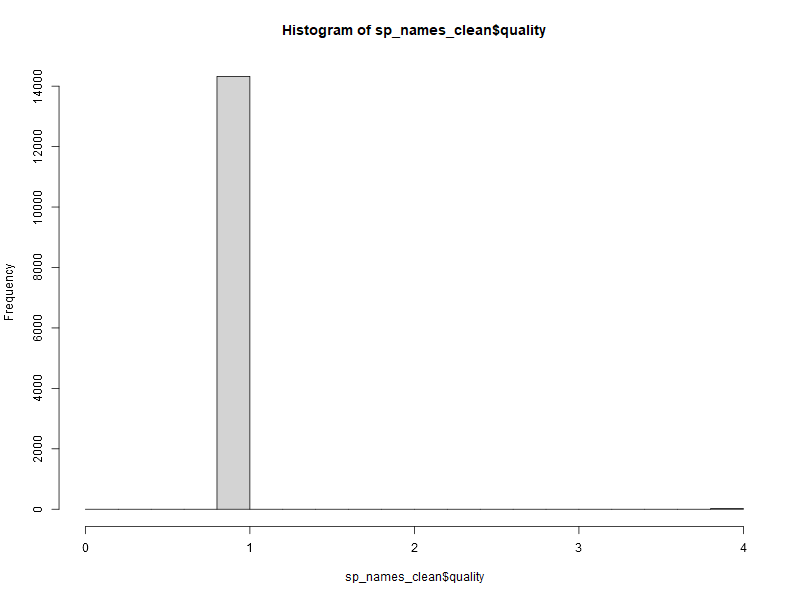

In [39]:
hist(sp_names_clean$quality)

Join clean scientific names with dataframe with all date

In [40]:
database_8 = database_7 %>%
  left_join(sp_names_clean, by = c("scientificName" = "scientificName"))%>%
  filter(quality %in% c(1, 2))

dimension_8 = database_8 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_8

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5471  0.936
2 BNDB           13099  2.24 
3 GBIF          566033 96.8  

In [41]:
len_8= sum(dimension_8$n)
cat("Dataset size:", len_8)

Dataset size: 584603

## 3.9. Coordinate precision

1 decimal is aprox 11 km of precision 

In [42]:
database_9 <-
  bdc_coordinates_precision(
    data = database_8,
    lon = "decimalLongitude",
    lat = "decimalLatitude",
    ndec = c(2) # number of decimals to be tested
  )%>%
  filter( .rou == TRUE)
dimension_9 = database_9 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

print(dimension_9)


bdc_coordinates_precision:
Flagged 11448 records
One column was added to the database.

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          5466  0.954
2 BNDB           11544  2.01 
3 GBIF          556145 97.0  


In [43]:
len_9= sum(dimension_9$n)
cat("Dataset size:", len_9)

Dataset size: 573155

## 3.10. Cooordinate cleaner

Create sci name using genus and specificEpithet

We filtered the dataset to keep only records that passed the tests for capitals (.cap), centroids (.cen), and outliers (.otl).

- cap → removes records with capitals that are not the main capital of the country.

- cen → removes records near administrative centroids (country or province centroids assigned by default).

- otl → removes geographic outliers that are far from the main distribution of the species.

This ensures that only records with reliable geographic positions remain, reducing the risk of biased results in downstream analyses.

In [44]:
database_9$decimalLatitude = as.numeric(database_9$decimalLatitude)
database_9$decimalLongitude = as.numeric(database_9$decimalLongitude)
database_10 <- CoordinateCleaner::clean_coordinates(
  x       = database_9,
  lon     = "decimalLongitude",
  lat     = "decimalLatitude",
  species = "names_clean",
  tests   = c(
    "capitals",     # cerca de capitales
    "centroids",    # cerca de centroides adm. (país/provincia)
    "institutions", # cerca de instituciones (museos, herbarios, zoos)
    "outliers"    # outliers geográficos por especie
  ),
  capitals_rad      = 100,
  centroids_rad     = 100,
  centroids_detail  = "both",   # país y provincia
  inst_rad          = 100,
  outliers_method   = "quantile",
  outliers_mtp      = 10,
  outliers_td       = 1000,
  outliers_size     = 10,
  zeros_rad         = 0.5
)


Testing coordinate validity
Flagged 0 records.
Testing country capitals
Flagged 0 records.
Testing country centroids
Flagged 0 records.
Testing geographic outliers
Flagged 15366 records.
Testing biodiversity institutions
Flagged 91 records.
Flagged 2331 of 573155 records, EQ = 0.


Warning message:
In cc_outl(otl_test, lon = lon, lat = lat, species = species, method = outliers_method,  :
  Species with fewer than 7 unique records will not be tested.


Filter data based in flags asigened 

In [45]:
database_10 = database_10 %>%
  filter(.cap == TRUE) %>%
  filter(.cen == TRUE) %>%
  filter(.otl == TRUE)

dimension_10 = database_10 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_10

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          3226  0.565
2 BNDB           11544  2.02 
3 GBIF          556145 97.4  

In [46]:
len_10= sum(dimension_10$n)
cat("Dataset size:", len_10)

Dataset size: 570915

Delete variables generated in data cleaning process

In [47]:
database_10 = database_10 %>%
  select(c(-.rou,-.val, -.cap, -.cen,-.otl , - .inst ,- .summary))


## 3.11. Replace Values - Errors detected

Replace Squamata = Reptilia

Replace Animal = Animalia

In [74]:
database_10 <- database_10 |>
  mutate(
    order = if_else(class == "Squamata", "Squamata", order),
    class = if_else(class == "Squamata", "Reptilia", class),
    kingdom = ifelse(kingdom =="Animal", "Animalia",kingdom)
  )

## 3.12. Validation of taxonomic names

In this case, we will only separate non-GBIF records for review, because we will use its backbone to validate

In [75]:
list_sp_gbif = database_10 |>
  dplyr::filter(database_name == "GBIF")|>
  pull(names_clean)|>
  unique()


In [77]:
sp_plants = database_10 |>
  dplyr::filter(kingdom == "Plantae")|>
  filter(database_name != "GBIF")|>
  filter(!names_clean %in%  list_sp_gbif) |>
  pull(names_clean)|>
  unique()|>
  na.omit()



sp_birds = database_10 |>
  dplyr::filter(class == "Aves"
  )|>
  filter(database_name != "GBIF")|>
    filter(!names_clean %in%  list_sp_gbif) |>
      pull(names_clean)|>
      unique()|>
        na.omit()


sp_mammals = database_10 |>
  dplyr::filter(class == "Mammalia"
  )|>
    filter(database_name != "GBIF")|>
    filter(!names_clean %in%  list_sp_gbif) |>
      pull(names_clean)|>
      unique()|>
        na.omit()


sp_amphibia = database_10 |>
  dplyr::filter(class == "Amphibia"
  )|>
    filter(database_name != "GBIF")|>
    filter(!names_clean %in%  list_sp_gbif) |>
      pull(names_clean)|>
      unique()|>
        na.omit()

sp_reptilia= database_10 |>
  filter(database_name != "GBIF")|>
  dplyr::filter(class == "Reptilia"
  )|>
    filter(!names_clean %in%  list_sp_gbif) |>
      pull(names_clean)|>
      unique()|>
        na.omit()

### Plants

Using GBIF db - Plants

In [50]:
query_names_plants <- bdc_query_names_taxadb(
  sci_name            = sp_plants,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Plantae",
  rank                = "kingdom",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 606 names queried in 0.4 minutes



In [51]:
query_names_plants = query_names_plants %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_gbif = query_names_plants%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_gbif

# A tibble: 7 × 3
  notes                                         n   prop
  <chr>                                     <int>  <dbl>
1 accepted                                    271 44.7  
2 accepted | replaceSynonym                   121 20.0  
3 accepted | wasMisspelled                     13  2.15 
4 accepted | wasMisspelled | replaceSynonym     4  0.660
5 heterotypic synonym                          11  1.82 
6 homotypic synonym                           185 30.5  
7 homotypic synonym | wasMisspelled             1  0.165

Using Catalogue of Life to complement the list of species not accepted by GBIF

In [52]:
query_names_plants =  query_names_plants %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_plants

# A tibble: 409 × 14
   original_search           distance notes     taxonID scientificName taxonRank
   <chr>                        <dbl> <chr>     <chr>   <chr>          <chr>    
 1 Aechmea wuelfinghoffii          NA accepted  GBIF:2… Aechmea wuelf… species  
 2 Tristerix longibracteatus       NA accepted… GBIF:4… Tristerix lon… species  
 3 Lycopodiella pendulina          NA accepted… GBIF:3… Palhinhaea pe… species  
 4 Pilea pulegifolia               NA accepted  GBIF:5… Pilea pulegif… species  
 5 Psychotria microbotrys          NA accepted  GBIF:2… Psychotria mi… species  
 6 Psychotria cauligera            NA accepted  GBIF:2… Psychotria ca… species  
 7 Alsophila paucifolia            NA accepted… GBIF:5… Cyathea pauci… species  
 8 Cinnamomum triplinerve          NA accepted… GBIF:4… Aiouea montana species  
 9 Fridericia florida              NA accepted  GBIF:7… Fridericia fl… species  
10 Guettarda crispiflora           NA accepted  GBIF:2… Guettarda cri… species  
# ℹ 399

### Birds

Using GBIF db - Birds

In [53]:
query_names_aves <- bdc_query_names_taxadb(
  sci_name            = sp_birds,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Aves",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 26 names queried in 0 minutes



In [54]:
query_names_aves = query_names_aves %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_aves = query_names_aves%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_aves

# A tibble: 3 × 3
  notes                         n  prop
  <chr>                     <int> <dbl>
1 accepted                      6  23.1
2 accepted | replaceSynonym     8  30.8
3 homotypic synonym            12  46.2

In [55]:
query_names_aves =  query_names_aves %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")
query_names_aves

# A tibble: 14 × 14
   original_search         distance notes       taxonID scientificName taxonRank
   <chr>                   <lgl>    <chr>       <chr>   <chr>          <chr>    
 1 Myrmelastes leucostigma NA       accepted |… GBIF:9… Schistocichla… species  
 2 Corythopis torquatus    NA       accepted    GBIF:2… Corythopis to… species  
 3 Aglaiocercus kingi      NA       accepted |… GBIF:2… Aglaiocercus … species  
 4 Cyanoloxia cyanoides    NA       accepted |… GBIF:9… Cyanocompsa c… species  
 5 Chloropipo unicolor     NA       accepted |… GBIF:2… Xenopipo unic… species  
 6 Amazilia franciae       NA       accepted |… GBIF:2… Uranomitra fr… species  
 7 Leptotila pallida       NA       accepted    GBIF:2… Leptotila pal… species  
 8 Pygochelidon cyanoleuca NA       accepted |… GBIF:2… Notiochelidon… species  
 9 Picoides fumigatus      NA       accepted |… GBIF:7… Leuconotopicu… species  
10 Pachyramphus minor      NA       accepted    GBIF:5… Pachyramphus … species  
11 Crypt

### Mammals

Using GBIF db - Mammals

In [ ]:
 query_names_mammals <- bdc_query_names_taxadb(
   sci_name            = sp_mammals,
   replace_synonyms    = TRUE,
   suggest_names       = TRUE, 
   suggestion_distance = 0.7,
   db                  = "gbif",
   rank_name           = "Mammalia",
   rank                = "class",
   parallel            = 8, # <--- Cambia esto a FALSE
   export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 73 names queried in 0.2 minutes



In [57]:
query_names_mammals= query_names_mammals %>%
   select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
     phylum, class, order , family,genus, specificEpithet )
 notes_sum_mammals= query_names_mammals%>%
   group_by(notes)%>%
   count()%>%
   ungroup()%>%
   mutate(prop = (n/sum(n))*100)

notes_sum_mammals

# A tibble: 5 × 3
  notes                         n  prop
  <chr>                     <int> <dbl>
1 accepted                     56 76.7 
2 accepted | replaceSynonym     5  6.85
3 accepted | wasMisspelled      6  8.22
4 homotypic synonym             1  1.37
5 notFound                      5  6.85

In [58]:
 query_names_mammals =  query_names_mammals %>%
   filter(taxonRank %in% c("subspecies", "species" ))%>%
   filter(taxonomicStatus == "accepted")

query_names_mammals

# A tibble: 67 × 14
   original_search      distance notes          taxonID scientificName taxonRank
   <chr>                   <dbl> <chr>          <chr>   <chr>          <chr>    
 1 Cryptotis albujai        0.71 accepted | wa… GBIF:1… Cryptotis nia… species  
 2 Anoura aequatoris       NA    accepted       GBIF:7… Anoura aequat… species  
 3 Anoura peruana          NA    accepted       GBIF:8… Anoura peruana species  
 4 Anoura fistulata        NA    accepted       GBIF:6… Anoura fistul… species  
 5 Dermanura glauca        NA    accepted | re… GBIF:4… Artibeus glau… species  
 6 Dermanura gnoma         NA    accepted | re… GBIF:4… Artibeus gnom… species  
 7 Artibeus lituratus      NA    accepted       GBIF:2… Artibeus litu… species  
 8 Carollia brevicauda     NA    accepted | re… GBIF:1… Carollia brev… species  
 9 Enchisthenes hartii     NA    accepted       GBIF:4… Enchisthenes … species  
10 Platyrrhinus ismaeli    NA    accepted       GBIF:5… Platyrrhinus … species  
# ℹ 57 m

### Amphibia

In [59]:
query_names_amphibia <- bdc_query_names_taxadb(
  sci_name            = sp_amphibia,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Amphibia",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)



Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 24 names queried in 0.2 minutes



In [60]:
query_names_amphibia= query_names_amphibia %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_amphibia= query_names_amphibia%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_amphibia

# A tibble: 5 × 3
  notes                                         n  prop
  <chr>                                     <int> <dbl>
1 accepted                                     13 54.2 
2 accepted | replaceSynonym                     5 20.8 
3 accepted | wasMisspelled                      4 16.7 
4 accepted | wasMisspelled | replaceSynonym     1  4.17
5 notFound                                      1  4.17

In [61]:
query_names_amphibia =  query_names_amphibia %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_amphibia

# A tibble: 23 × 14
   original_search          distance notes      taxonID scientificName taxonRank
   <chr>                       <dbl> <chr>      <chr>   <chr>          <chr>    
 1 Hyloscirtus dispersus        0.76 accepted … GBIF:9… Hyloscirtus d… species  
 2 Phyllomedusa tomopterna     NA    accepted … GBIF:2… Callimedusa t… species  
 3 Phyllonastes lochites       NA    accepted … GBIF:2… Noblella loch… species  
 4 Phyllomedusa ecuatoriana    NA    accepted … GBIF:2… Callimedusa e… species  
 5 Phyllonastes personinus      0.74 accepted … GBIF:1… Hyloxalus per… species  
 6 Hyloscirtus maycu            0.78 accepted … GBIF:9… Hyloscirtus m… species  
 7 Centrolene pipilata          0.9  accepted … GBIF:2… Centrolene pi… species  
 8 Caecilia crassisquama       NA    accepted   GBIF:5… Caecilia cras… species  
 9 Pristimantis ledzeppelin     0.71 accepted … GBIF:2… Pristimantis … species  
10 Pristimantis metabates      NA    accepted   GBIF:2… Pristimantis … species  
# ℹ 13 m

### Reptilia

In [80]:
query_names_reptilia <- bdc_query_names_taxadb(
  sci_name            = sp_reptilia,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Reptilia",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)



Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 11 names queried in 0.1 minutes



In [81]:
query_names_reptilia= query_names_reptilia %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_reptilia= query_names_reptilia%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_reptilia

# A tibble: 4 × 3
  notes                         n  prop
  <chr>                     <int> <dbl>
1 accepted                      7 63.6 
2 accepted | replaceSynonym     1  9.09
3 accepted | wasMisspelled      1  9.09
4 notFound                      2 18.2 

In [82]:
query_names_reptilia =  query_names_reptilia %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_reptilia

# A tibble: 9 × 14
  original_search          distance notes       taxonID scientificName taxonRank
  <chr>                       <dbl> <chr>       <chr>   <chr>          <chr>    
1 Mabuya altamazonica         NA    accepted |… GBIF:5… Varzea altama… species  
2 Chironius scurrula           0.89 accepted |… GBIF:2… Chironius scu… species  
3 Anolis sagrei               NA    accepted    GBIF:4… Anolis sagrei  species  
4 Corallus batesii            NA    accepted    GBIF:8… Corallus bate… species  
5 Pholidobolus vertebralis    NA    accepted    GBIF:9… Pholidobolus … species  
6 Stenorrhina degenhardtii    NA    accepted    GBIF:2… Stenorrhina d… species  
7 Enyalioides laticeps        NA    accepted    GBIF:2… Enyalioides l… species  
8 Hemidactylus mabouia        NA    accepted    GBIF:5… Hemidactylus … species  
9 Andinosaura petrorum        NA    accepted    GBIF:1… Andinosaura p… species  
# ℹ 8 more variables: taxonomicStatus <chr>, kingdom <chr>, phylum <chr>,
#   class <chr>,

### Join Querys

In [83]:
all_querys = rbind(query_names_plants,query_names_aves,query_names_amphibia,query_names_mammals, query_names_reptilia)
all_querys

# A tibble: 522 × 14
   original_search           distance notes     taxonID scientificName taxonRank
   <chr>                        <dbl> <chr>     <chr>   <chr>          <chr>    
 1 Aechmea wuelfinghoffii          NA accepted  GBIF:2… Aechmea wuelf… species  
 2 Tristerix longibracteatus       NA accepted… GBIF:4… Tristerix lon… species  
 3 Lycopodiella pendulina          NA accepted… GBIF:3… Palhinhaea pe… species  
 4 Pilea pulegifolia               NA accepted  GBIF:5… Pilea pulegif… species  
 5 Psychotria microbotrys          NA accepted  GBIF:2… Psychotria mi… species  
 6 Psychotria cauligera            NA accepted  GBIF:2… Psychotria ca… species  
 7 Alsophila paucifolia            NA accepted… GBIF:5… Cyathea pauci… species  
 8 Cinnamomum triplinerve          NA accepted… GBIF:4… Aiouea montana species  
 9 Fridericia florida              NA accepted  GBIF:7… Fridericia fl… species  
10 Guettarda crispiflora           NA accepted  GBIF:2… Guettarda cri… species  
# ℹ 512

### Replace taxonomical data

In [84]:
all_sp_acepted = c(list_sp_gbif, all_querys$original_search) # lista de especies de gbif y consultadas
database_11 = database_10 %>%
  filter(names_clean %in% all_sp_acepted)

In [85]:
dimension_11 = database_11 %>%
  group_by(database_name)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

dimension_11

# A tibble: 3 × 3
  database_name      n   prop
  <chr>          <int>  <dbl>
1 BIOWEB          3104  0.544
2 BNDB           10947  1.92 
3 GBIF          556145 97.5  

In [86]:
len_11= sum(dimension_11$n)
cat("Dataset size:", len_11)

Dataset size: 570196

In [87]:


tax_update <- all_querys |>
  select(
    original_search,
    taxonID,
    scientificName,
    taxonRank,
    taxonomicStatus,
    kingdom,
    phylum,
    class,
    order,
    family,
    genus,
    specificEpithet
  ) |>
  rename(names_clean = original_search)

database_11_resuelto <- database_11 |>
  left_join(tax_update, by = "names_clean", suffix = c("", ".new")) |>
  mutate(
    scientificName   = coalesce(scientificName.new, scientificName),
    kingdom          = coalesce(kingdom.new, kingdom),
    phylum           = coalesce(phylum.new, phylum),
    class            = coalesce(class.new, class),
    order            = coalesce(order.new, order),
    genus            = coalesce(genus.new, genus),
    specificEpithet  = coalesce(specificEpithet.new, specificEpithet)
  ) |>
  select(
    -scientificName.new,
    -kingdom.new,
    -phylum.new,
    -class.new,
    -order.new,
    -genus.new,
    -specificEpithet.new,
    -gbifID,
    -".coordinates_outOfRange",
    -uncer_terms,
    -".uncer_terms" ,
    -".infraesp_names" ,
    -names_clean,
    -quality,
    -taxonID,
    -taxonRank.new,
    -taxonomicStatus


  )|>mutate(scientificName = paste(genus,specificEpithet, sep = " " ))

# 4. Export results

In [88]:

write.csv(database_11_resuelto, "../../../DATOS/Datasets/Biodiversidad/biodiversidad_ocurrences_clean.csv", row.names = FALSE)

# 5. Resume of clenaning

In [89]:
len_data = c(len_0, len_1, len_2, len_3, len_4, len_5, len_6, len_7, len_8, len_9, len_10, len_11)
steps = c("1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11","12")
# Create vectors for the data frame

# Create the data frame
cleaning_data <- data.frame(
  len_data = len_data,
  steps = steps)

  cleaning_data

write.csv(cleaning_data, "Results/data_proccesing_cleaning/cleaning_data.csv", row.names = FALSE)